### PRiAD - Sprawdzian z analizy eksploracyjnej danych Z23

Test obejmuje zagadnienia dotyczace analizy eksploracyjnej danych (ćwiczenia PRiAD2 oraz PRiAD3, wraz z wcześniejszymi wprowadzającymi do Pythona tj. PRiAD0 i PRiAD1). W czasie testu można korzystać z instrukcji ćwiczeń. **Natomiast wszelka wymiana informacji pomiędzy osobami piszącymi sprawdzian jest zabroniona !**

Łączna liczba punktów do zdobycia wynosi 10, po odpowiednio:2,2,3,3 pkt za kolejne zadania.

Powodzenia !!

---
**Imię, nazwisko i numer indeksu:** 

Od razu też należy zmienić nazwę pliku na `PRiAD sprawdzian - Imie Nazwisko.ipynb`

---

W pierwszym kroku należy pobrać indywidualny zestaw danych. Zestaw ten składa się z pewnej liczby obiektów opisanych pewną liczbą atrybutów opisujących (cech, zmiennych), naleących do pewnej liczby klas (kategorii). Przynależność do klasy jest zapisana w ostatnim atrybucie (decyzyjnym, opisywanym). Zestaw danych został zapisany w pliku `.csv` i znajduje się pod następującym adresem sieciowym 

'http://home-www.ee.pw.edu.pl/~iwanowsm/PRiAD/grX/X_123456_Jan_Kowalski.csv'

przy czym w miejsce X ('.../gr**X**/**X**_...') należy wstawic swój numer grupy (**1** - wt 10:15; **2** - wt 14:15; **3** - wt 16:15; **4** - sr 14:15), zamiast '123456' należy wpisać swój numer indeksu, a w miejsce słów 'imie' i 'nazwisko' wpisujemy swoje imię i nazwisko **bez polskich znaków**. Plik należy wczytać przy pomocy odpowiedniej komendy Pythona, która powinna zostać umieszczona w kodzie !

---

**Zadanie 1** (3 punkty)

Wczytaj zbiór, a następnie wyznacz, WPISUJĄC PONIŻEJ STOSOWNE FRAGMENTY KODU:
* łączna liczbę obiektów (obserwacji)
* liczbę klas 
* liczbę obiektów w każdej klasie
* liczbę atrybutów/cech
* liczbę brakujących danych

Na potrzeby dalszej analizy usuń obiekty z brakującymi danymi.

In [44]:
# Zadanie 1 - miejsce na rozwiazanie
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('dane.csv')
d0 = df.drop(columns=['Unnamed: 0'])
d0.head()
# liczba obiektów
print("liczba obiektow:", d0.shape[0])

# liczba klas
print("liczba klas:", d0.groupby('klasa').ngroups)

# liczba obiektów w każdej klasie
klasy = d0.groupby('klasa')
items = []
for obj in klasy:
    items.append(len(obj))
print("liczba obiektow w klasie", items)
"""
uwaga, to nie działa bo grupy z .groupby() są typu krotki, więc ich len() to zawsze 2
"""

# liczba atrybutów
print("liczba atrybutow:", d0.shape[1])

# liczba danych brakujących
print("liczba danych brakujacych:", d0.isna().sum().sum())

# usunięcie danych brakujących
dna = d0.dropna()


liczba obiektow: 375
liczba klas: 5
liczba obiektow w klasie [2, 2, 2, 2, 2]
liczba atrybutow: 10
liczba danych brakujacych: 142


--- 
**Zadanie 2** (2 punkty)

Przeanalizuj zmienność poszczególnych (pojedynczych) atrybutów w całym zbiorze (bez odniesienia do klas) oraz odrębnie w poszczególnych klasach. Wyniki przedstaw również na odpowiednim wykresie. Przygotuj odpowiedni kod, wnioski uzasadnij.

C:\Users\wrsee\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\wrsee\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


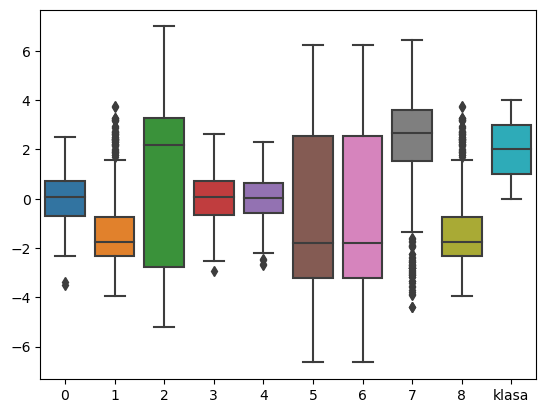

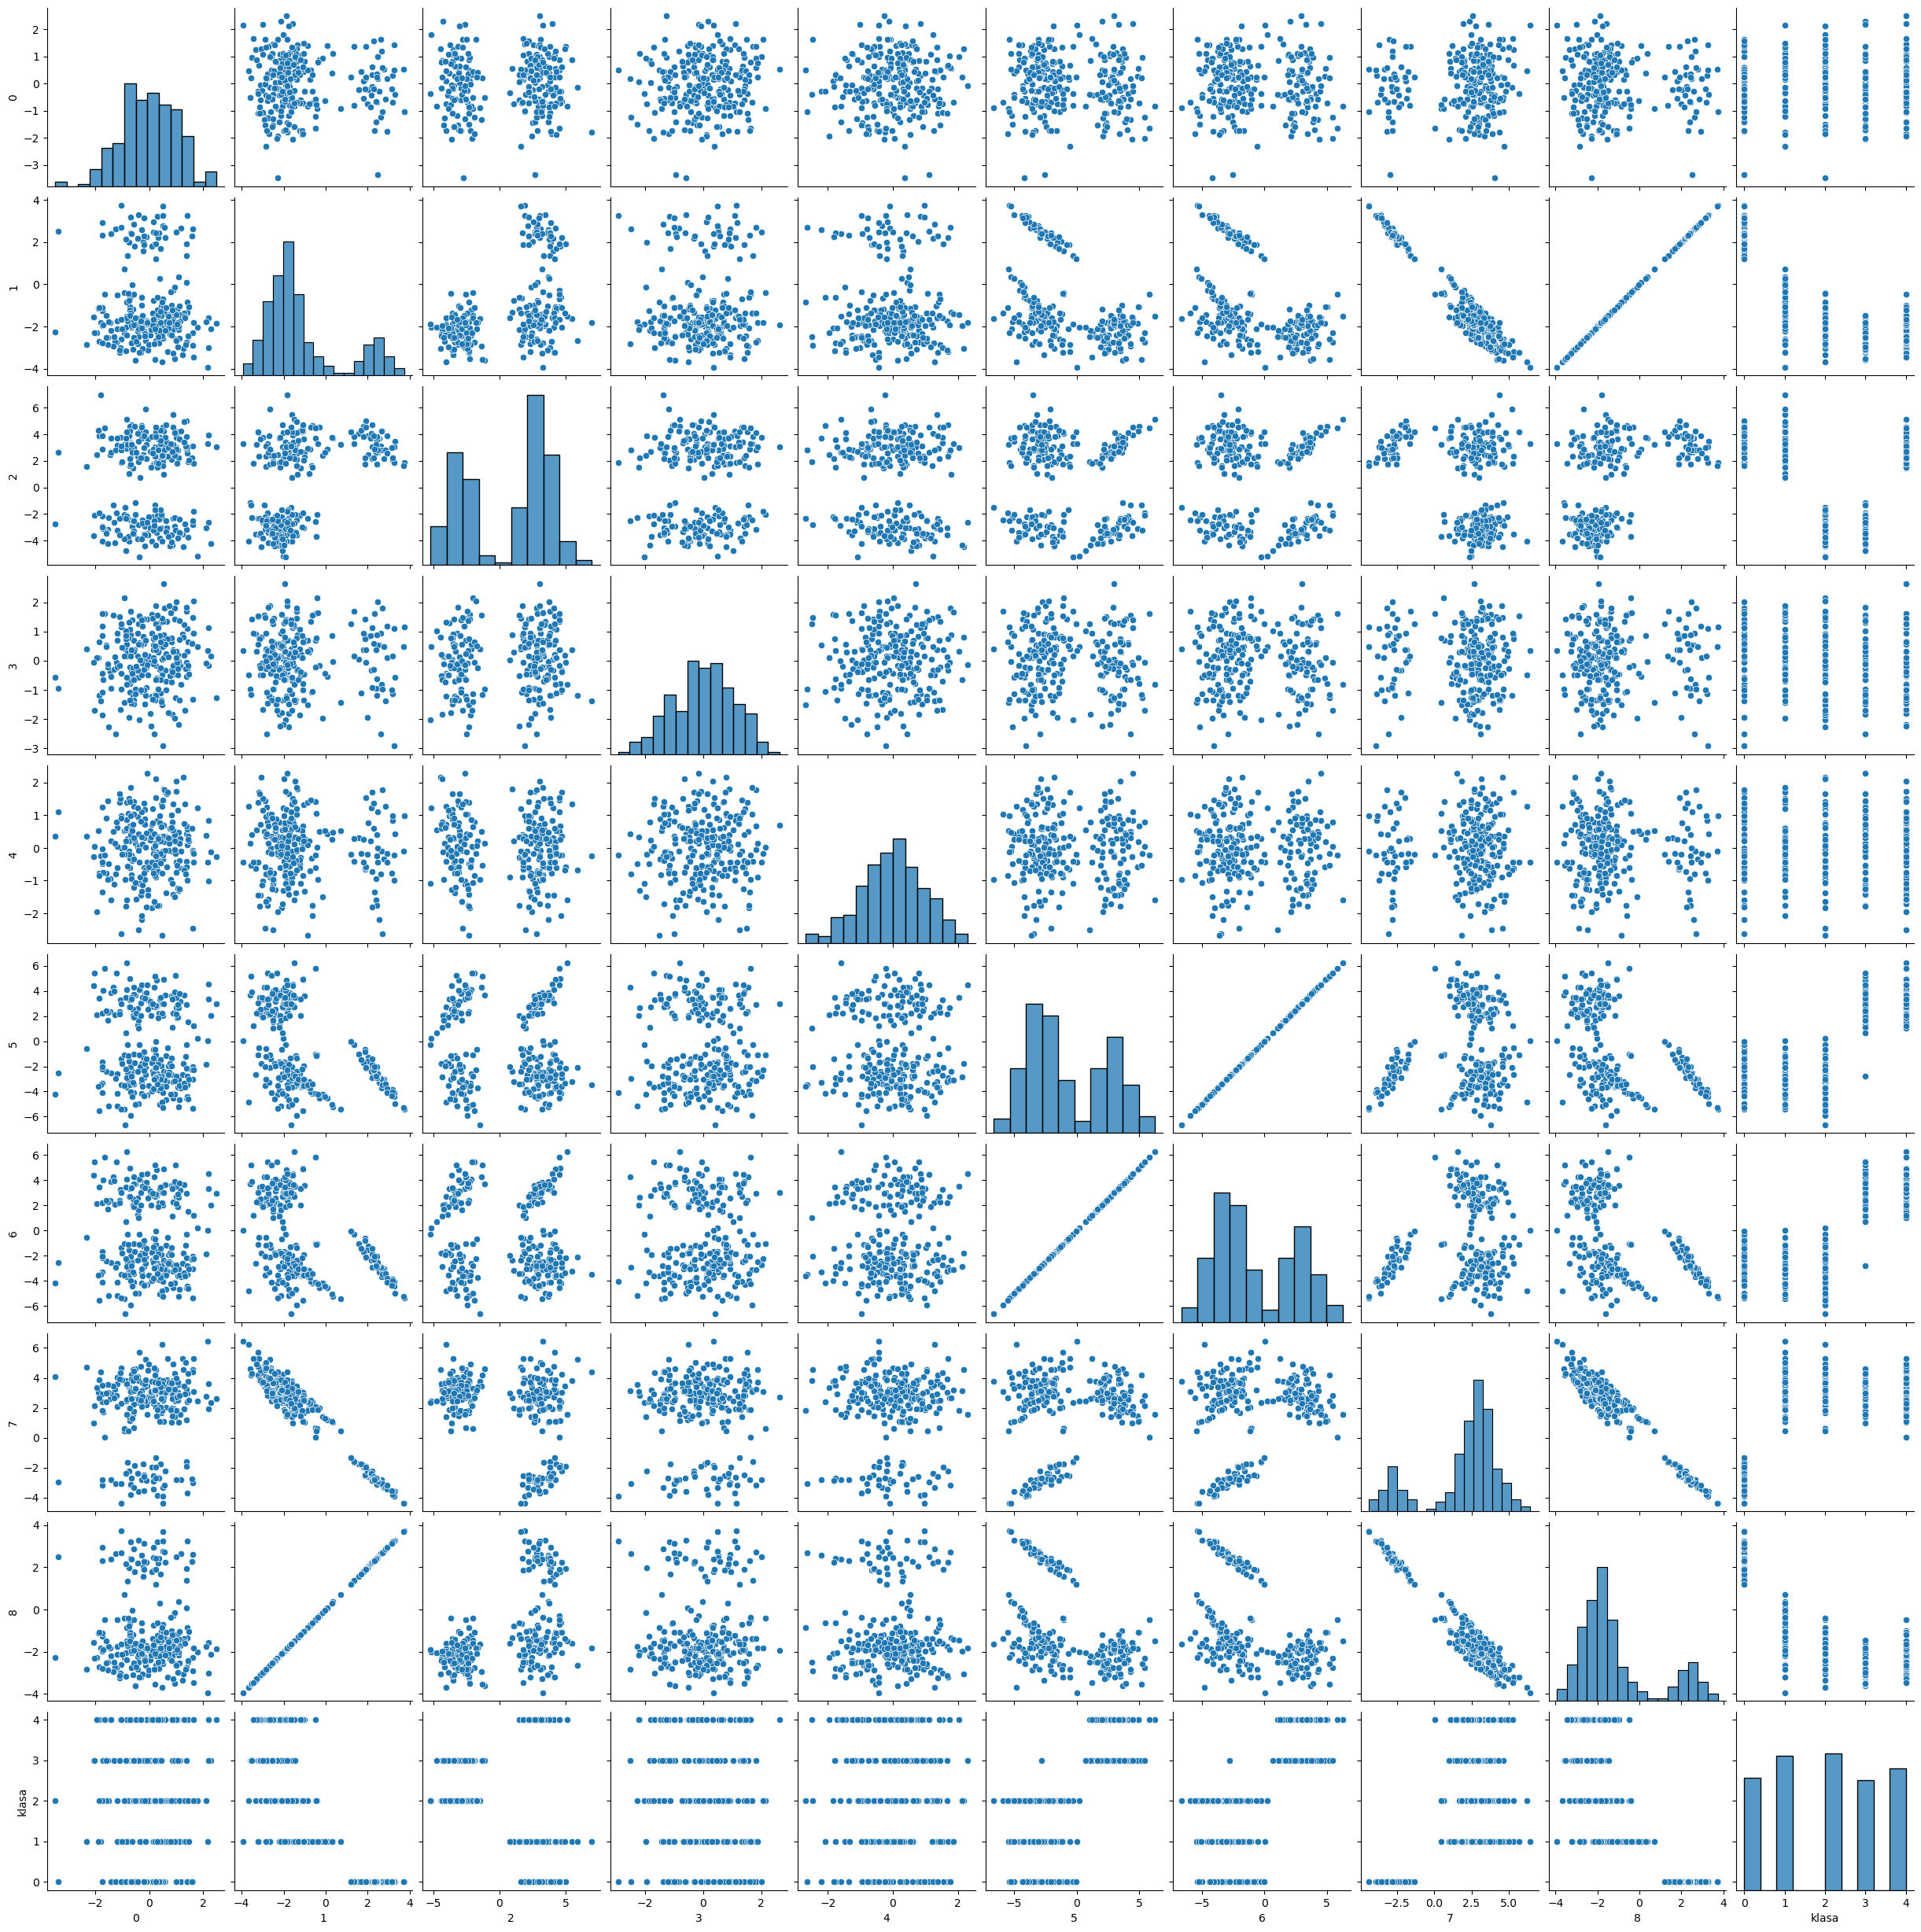

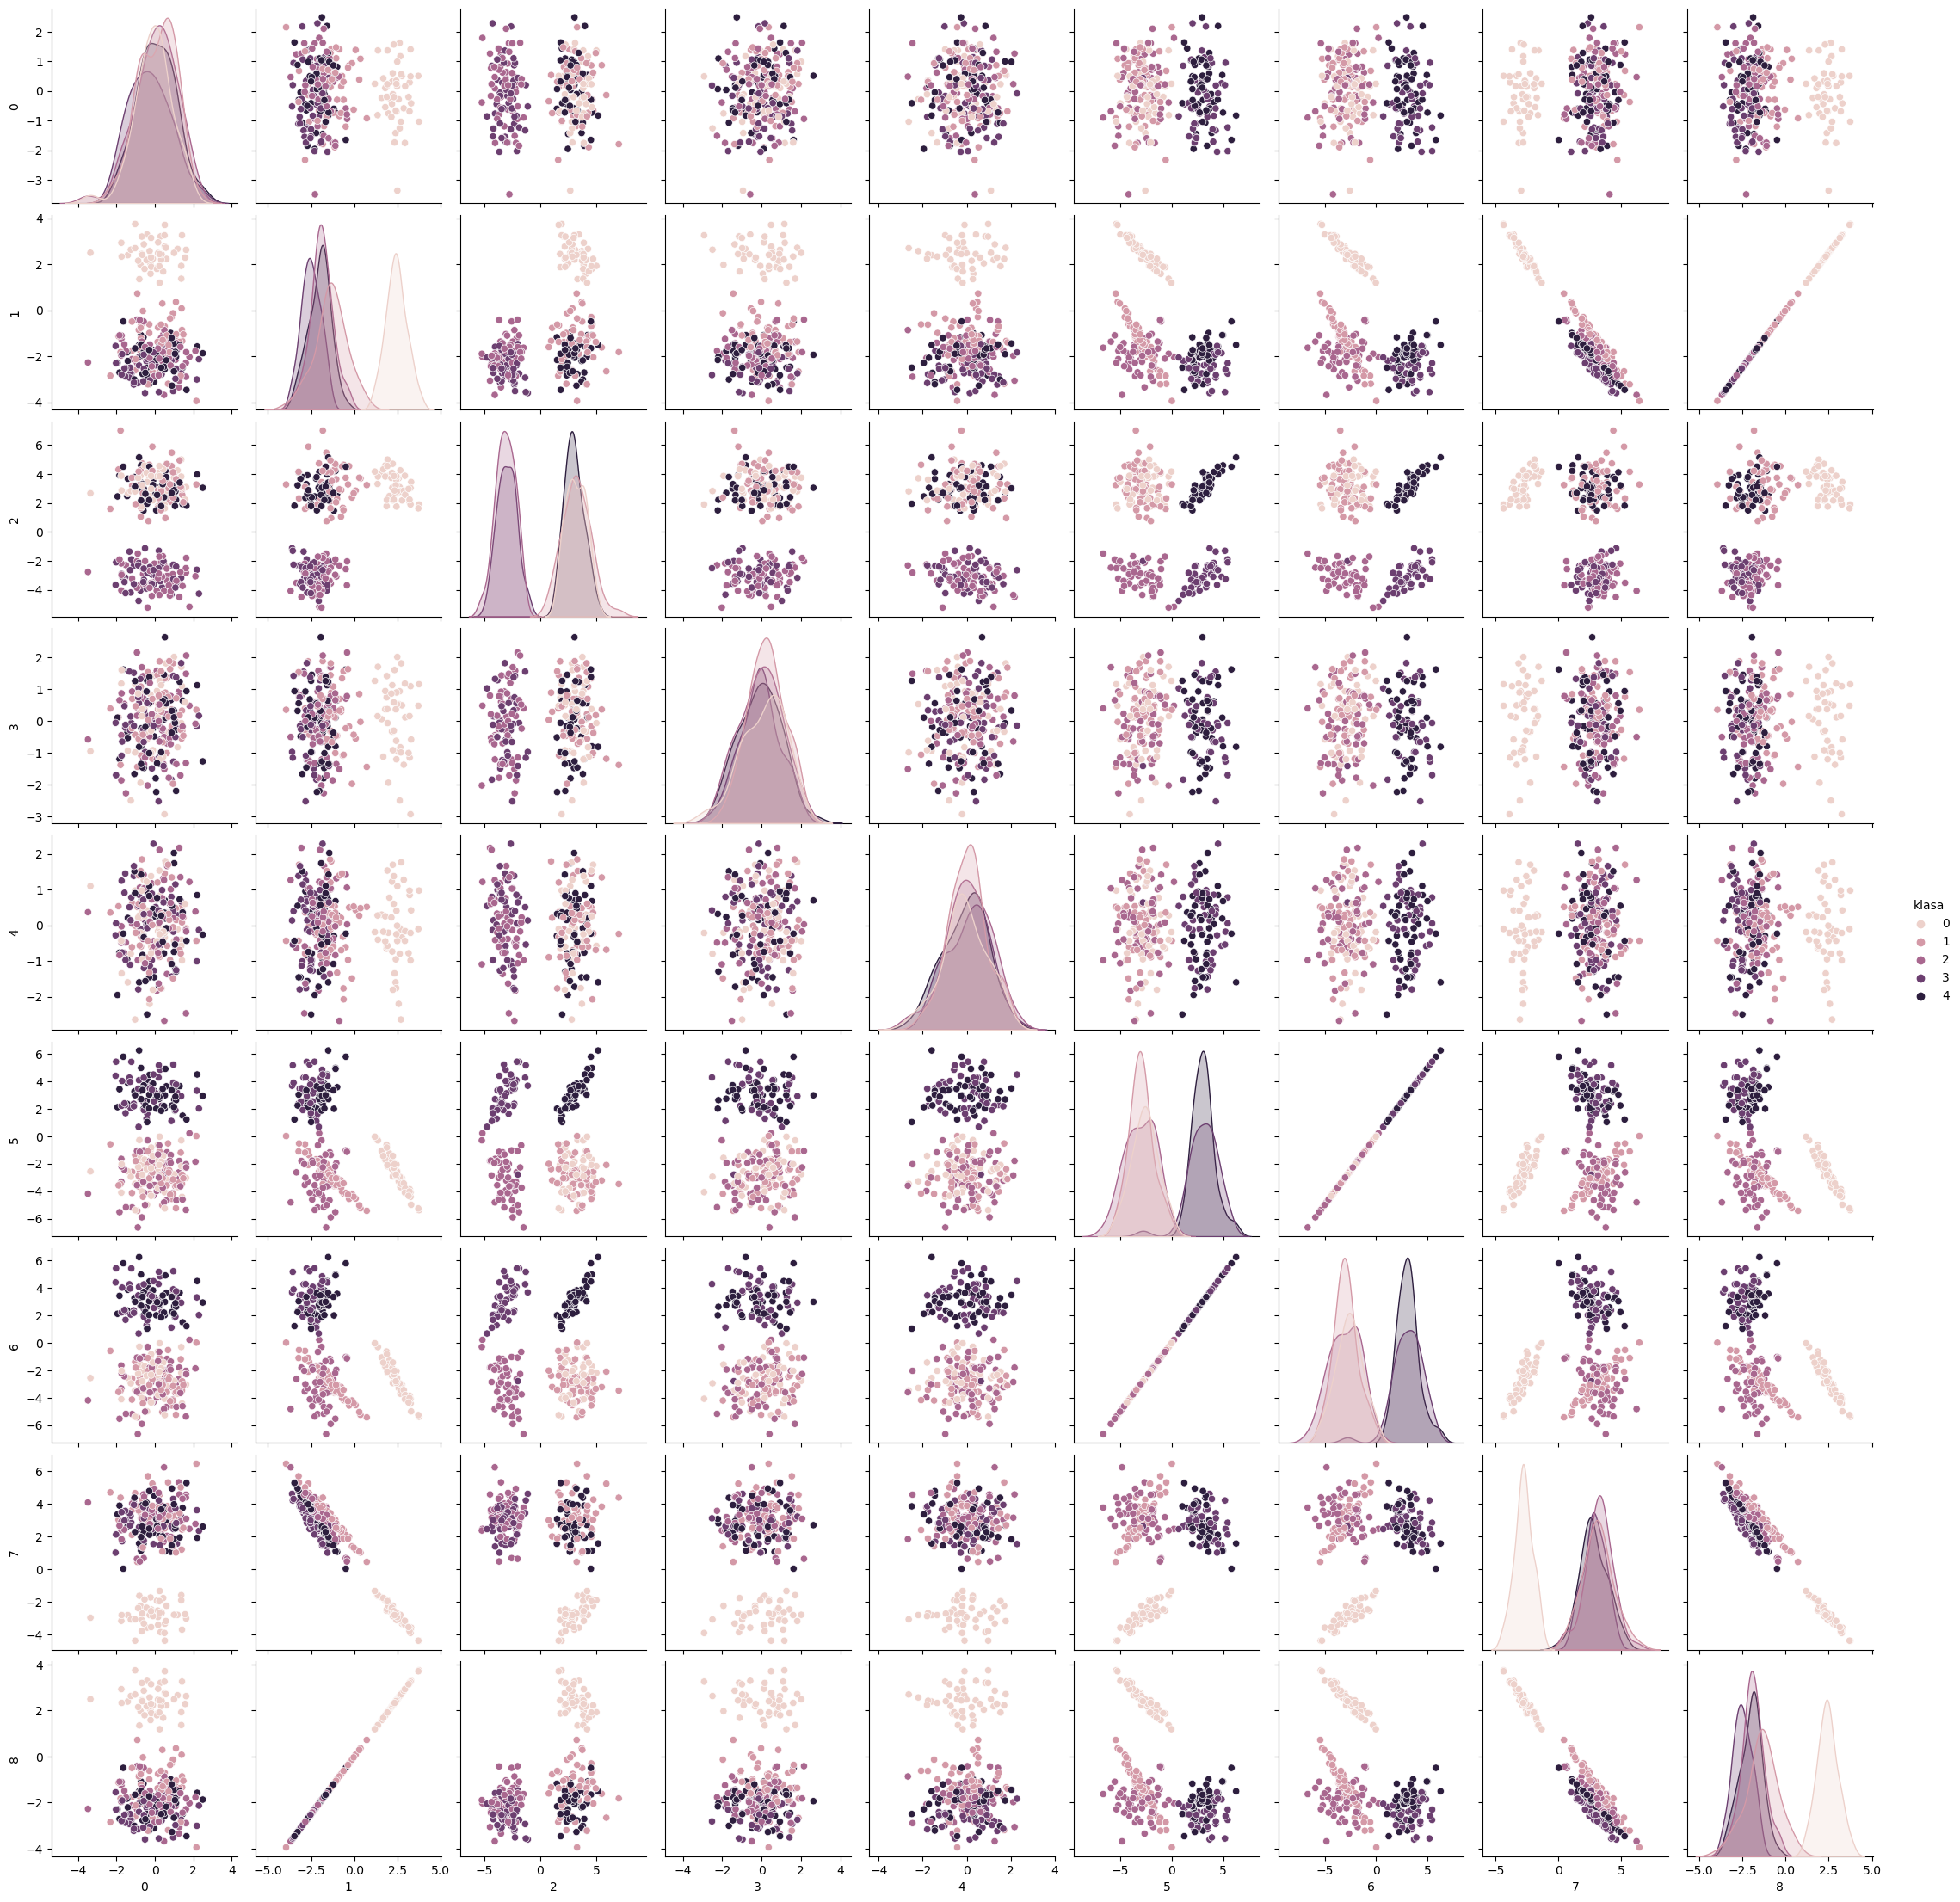

In [58]:
# Zadanie 2 - miejsce na rozwiązanie
# plt.figure(figsize=(25,8))
sns.boxplot(dna)
sns.pairplot(dna, kind = 'scatter')
sns.pairplot(dna, hue = 'klasa', kind = 'scatter')
plt.show()



*Zadanie 2 - wnioski*
* widać skupiska danych nadmiarowych dla atrybutów 2, 6, 7
* największą zmienność wykazują atrybuty 0, 3, 4 (szerokie wykresy, dosyć wyrównane). w przypadku podziału na klasy większość atrybutów ma zbliżoną zmienność, jednak dla klas 1 i 2 atrybuty 5 i 6 mają większą zmiennosć niż dla pozostałych

---
**Zadanie 3**  (3 punkty)

Na podstawie pierwotnie wygenerowanych danych oceń:
1. stopień korelacji poszczególnych atrybutów,
2. w jakim stopniu poszczególne cechy umożliwiają rozróżniene klas.

Wykonaj odpowiednie wizualizacje, wpisz stosowny fragment kodu, a odpowiedź uzasadnij.

<Axes: >

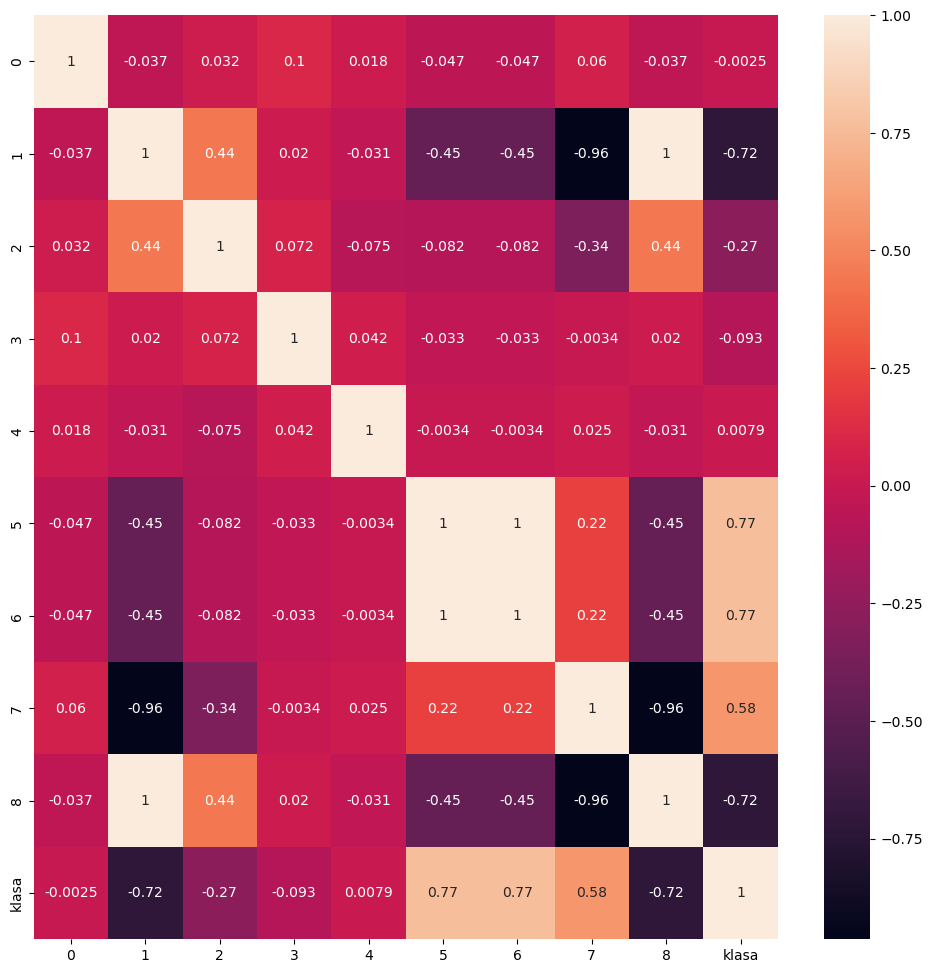

In [57]:
# Zadanie 3 - miejsce na rozwiązanie
plt.figure(figsize = (12, 12), dpi = 100)
sns.heatmap(dna.corr(),annot = dna.corr())

# Zadanie 3 - wnioski
* istnieją atrybuty skorelowane idealnie dodatnio - konkretnie atrybuty 1 i 8, 5 i 6. Dodatkowo atrybuty 7 i 8 oraz 1 i 7 charakteryzują się bardzo silną korelacją ujemną (współczynnik -0.97). Pozostałe pary atrybutów są skorelowane w małym stopniu, jedynie 2 i 1 oraz 5 i 6 wykazują większą korelację.
* przydatne do rozróżniania klas będą m.in. pary atrybutów 6 i 7 (rozróżnienie klasy 0 od 1/2 oraz 3/4), 2 i 6 (rozróżnienie klas 2, 3 i 4 od klasy 0 lub 1). Jest to spowodowane dobrym rozrzutem na wykresach punktowych.

---
**Zadanie 4** (2 punkty)

Dokonując wymaganych analiz oceń, czy i ewentualnie które atrybuty (zmienne, cechy) można uznać za nadmiarowe. Napisz stosowny fragment kodu, a końcową odpowiedź uzasadnij.

<Axes: >

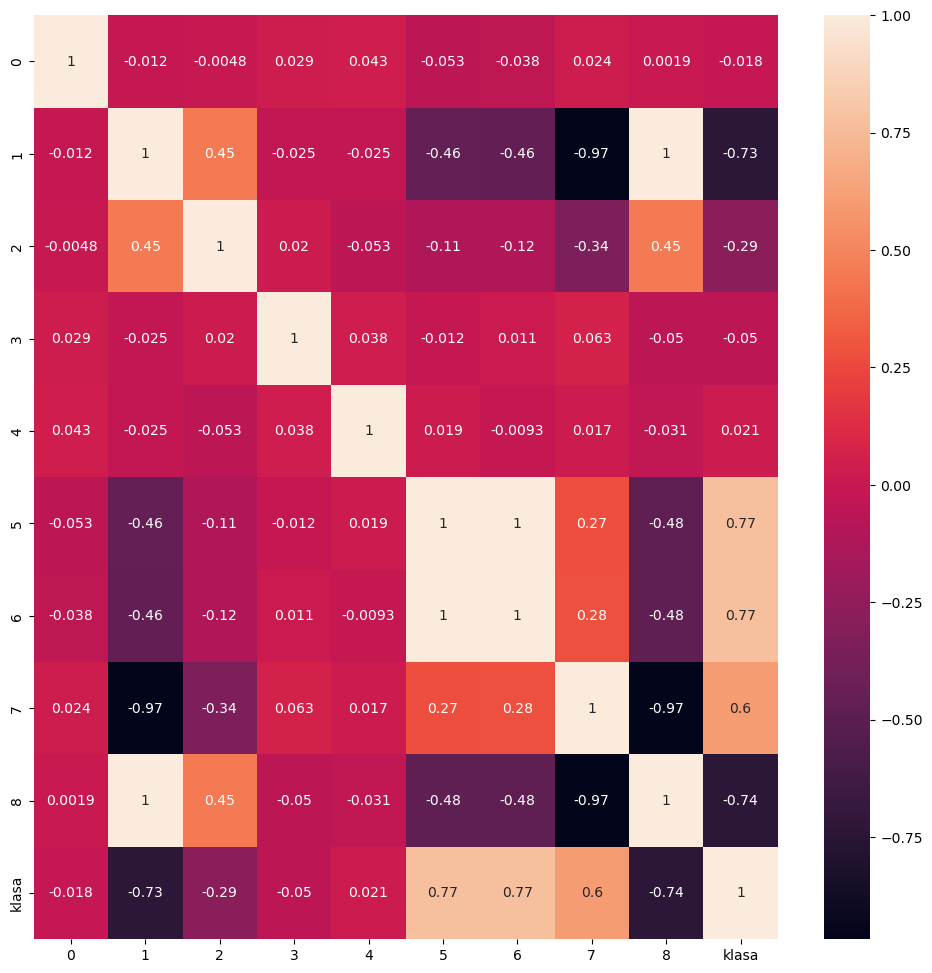

In [50]:
# Zadanie 4 - miejsce na rozwiązanie
plt.figure(figsize = (12, 12), dpi = 100)
sns.heatmap(d0.corr(),annot = d0.corr())


*Zadanie 4 - wnioski*
* Można za nadmiarowe uznać po jednym z atrybutów z pary 1-8 i 5-6, ponieważ są skorelowane idealnie. Można też tak powiedzieć o atrybutach 7/8 i 1/7, gdyż są skorelowane, jednak ujemnie.
* Pozostałe atrybuty są skorelowane w dopuszczalnym stopniu.

---

**Pracę należy wgrać do ISOD-a w terminie podanym przez prowadzącego !**